<div style="width: 100%; text-align: center;">
    <div style="background-color:#007F00; padding: 0.5rem;">
        <h1 style="font-weight: bold; font-size: 2.5em; color: black;"> AGRHYMET CENTRE CLIMATIQUE REGIONAL POUR L'AFRIQUE DE L'OUEST ET LE SAHEL</h1>
   </div>

   <div style="text-align: center;">
  <img src="https://www.sareco.org/wp-content/uploads/2017/07/plrDvYX1.jpg" width="200">
</div>

<a id="1"></a>
### <p style="padding:10px;background-color:#000000 ;margin:0;color:#007F00;font-family:#newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500"> Sélection automatique des sous-bassins par zone d'étude </p>

## Objectif

Éviter de saisir les points d'intérêt à la main : à partir d'une **zone
d'étude** (un pays -- code ISO3 -- ou votre propre shapefile/GeoPackage),
sélectionner automatiquement les **sous-bassins HydroBASINS niveau 5** dont
l'exutoire (ou le polygone, selon la méthode) tombe dans cette zone, puis
enchaîner **tout le reste de la chaîne sans aucune modification** :
téléchargement historique + prévision, seuils de quantile, classification du
risque, cartes journalières -- cadrées sur la zone d'étude.

Ce notebook complète `download_glofas_data.ipynb` et `previsions_risque.ipynb` :
il ne les remplace pas, il ajoute simplement une étape 0 (`glofas_basins.py`)
qui **génère** le fichier de points (`ID,LONG,LAT`) que ces deux notebooks
attendent en entrée. Une fois ce fichier généré, vous pouvez aussi bien
continuer ici que reprendre dans les notebooks existants.

**Couches statiques nécessaires** (dossier `static/`, fournies avec l'atelier) :

- `afrique.gpkg` : limites administratives des pays d'Afrique (colonne
  `GMI_CNTRY` = code ISO3).
- `hybas_af_lev05_with_outlets.gpkg` (ou `hybas_af_lev05_outlet_coordinates.csv`,
  plus léger mais sans les polygones) : sous-bassins HydroBASINS niveau 5,
  avec les coordonnées de leur exutoire (`OUTLET_LONGITUDE`/`OUTLET_LATITUDE`).

**Dépendance supplémentaire** : `geopandas` (+ `pyogrio`, `shapely`) --
inclus dans `environment.yml`/`requirements.txt` mis à jour ; sinon
`pip install geopandas pyogrio shapely`.

**Chaque zone dans son propre dossier** : tous les résultats (points, séries,
seuils, cartes...) sont écrits sous `resultats/<COUNTRY_NAME>/`,
`glofas_data/<COUNTRY_NAME>/` et `glofas_forecast_data/<COUNTRY_NAME>/` --
traiter une nouvelle zone (autre `COUNTRY_NAME` à l'étape 1) n'écrase jamais
les résultats d'une zone précédente.

In [1]:
import sys, os
from pathlib import Path
from datetime import date, timedelta

from glofas_basins import (
    resolve_zone, build_zone_points, zone_bbox_area,
    select_basins_in_zone, basins_to_points, export_points_csv,
)
from glofas_download import download_glofas_discharge
from glofas_extract import extract_glofas_at_points
from glofas_forecast import download_glofas_forecast, extract_glofas_forecast_at_points
from glofas_risk import compute_historical_thresholds, classify_forecast_risk
from glofas_visualize import (
    build_risk_map, generate_daily_risk_maps,
    build_static_risk_map, generate_daily_static_risk_maps,
    generate_static_risk_map_grid, build_max_severity_map,
)

## Configuration EWDS

Comme dans `download_glofas_data.ipynb`/`previsions_risque.ipynb` : le
GloFAS (historique **et** prévision) est servi par l'EWDS, distinct du CDS
« classique » -- d'où un fichier de configuration `cdsapi` séparé
(`~/.cdsapirc-ewds`) pour ne pas entrer en conflit avec une configuration
CDS déjà en place (ex. pour le CMIP6/S2S). **Cette cellule doit être
exécutée avant toute cellule de téléchargement ci-dessous** (§ 3 et § 5) --
sans elle, `cdsapi` retombe sur `~/.cdsapirc` par défaut, qui pointe vers
le CDS et ne connaît pas les jeux de données GloFAS (erreur
`404 ... dataset cems-glofas-historical not found`).

In [2]:
ewds_config = Path.home() / ".cdsapirc-ewds"

if not ewds_config.exists():
    raise FileNotFoundError(f"Configuration EWDS introuvable : {ewds_config}")

os.environ["CDSAPI_RC"] = str(ewds_config)
print("Configuration sélectionnée :", ewds_config)

Configuration sélectionnée : C:\Users\ARSENE\.cdsapirc-ewds


## 1. Définir la zone d'étude, ses dossiers de résultats et son emprise

Deux façons de définir la zone, au choix (une seule à la fois) :

- **Code ISO3** : `iso3="CMR"` (Cameroun), `"TCD"` (Tchad), `"NGA"`
  (Nigéria), etc. -- recherché dans la colonne `GMI_CNTRY` de `afrique.gpkg`.
- **Zone personnalisée** : `boundary_path="mon_bassin.shp"` (ou `.gpkg`,
  `.geojson`) -- toutes les entités du fichier sont fusionnées en une seule
  géométrie (peu importe qu'il y en ait une ou plusieurs).

`buffer_km` (optionnel) ajoute une marge autour de la zone, utile pour ne
pas exclure un sous-bassin juste à cheval sur la frontière.

`COUNTRY_NAME` identifie la zone traitée et sert de nom de dossier pour
**tous** ses résultats (`RESULTS_DIR`, `GLOFAS_DATA_DIR`,
`GLOFAS_FORECAST_DIR` ci-dessous) : pour traiter un autre pays/une autre
zone, changez uniquement `COUNTRY_NAME` (et `iso3`/`boundary_path`), puis
relancez le notebook -- rien ne se mélange ni ne s'écrase entre deux zones.

L'emprise de téléchargement (`area`, nord/ouest/sud/est) n'est plus à
saisir à la main : `zone_bbox_area(zone)` la calcule automatiquement à
partir du rectangle englobant de la zone. `AREA_MARGIN_DEG` (`0` par défaut,
comme demandé) permet de l'élargir, en degrés, si besoin -- par exemple pour
ne pas couper un sous-bassin dont l'exutoire est tout proche du bord.

In [3]:
COUNTRY_NAME = "BFA"                             # ex. "CMR", "TCD", "NGA"... ou un nom libre pour une zone personnalisée (boundary_path)

zone = resolve_zone(
    iso3=COUNTRY_NAME,                             # ou : boundary_path="ma_zone.shp"
    countries_path="static/afrique.gpkg",
    buffer_km=0,
)
print("Zone :", zone.label, "--", zone.source)

# Dossiers de résultats dédiés à cette zone -- traiter un autre pays/zone
# (autre COUNTRY_NAME) n'écrase jamais ceux-ci.
RESULTS_DIR = Path("resultats") / COUNTRY_NAME
GLOFAS_DATA_DIR = Path("glofas_data") / COUNTRY_NAME
GLOFAS_FORECAST_DIR = Path("glofas_forecast_data") / COUNTRY_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Emprise de téléchargement (nord, ouest, sud, est), déduite automatiquement
# de la zone. AREA_MARGIN_DEG (0 par défaut) l'élargit si besoin (degrés).
AREA_MARGIN_DEG = 0.0
zone_area = zone_bbox_area(zone, margin_deg=AREA_MARGIN_DEG)
print("Emprise de téléchargement (N, O, S, E) :", zone_area)

Zone : BFA -- static/afrique.gpkg (GMI_CNTRY=BFA)
Emprise de téléchargement (N, O, S, E) : (15.08277702331543, -5.520833969116211, 9.395692825317383, 2.39792537689209)


## 2. Sélectionner les sous-bassins et générer le fichier de points

`method` :

- `"outlet"` (défaut) -- l'exutoire du sous-bassin tombe dans la zone.
  Fonctionne avec le GeoPackage complet **ou** le CSV plat des coordonnées
  d'exutoire (pas besoin des polygones) -- c'est aussi la méthode la plus
  cohérente avec le reste de la chaîne (l'extraction GloFAS se fait
  justement au pixel le plus proche de ce point).
- `"intersects"` -- le polygone du sous-bassin touche la zone (au moins
  partiellement) ; plus permissif, capture les bassins transfrontaliers.
  Nécessite le GeoPackage/shapefile complet (polygones).
- `"within"` -- le polygone du sous-bassin est entièrement contenu dans la
  zone ; plus strict. Nécessite également les polygones.

Le résultat (`resultats/<COUNTRY_NAME>/points.csv`) a exactement le format
attendu par `glofas_download`/`glofas_extract`/`glofas_forecast` (colonnes
`ID`, `LONG`, `LAT`).

In [15]:
selection, table = select_basins_in_zone(
    zone,
    basins="static/hybas_af_lev05_with_outlets.gpkg",  # ou le .csv (method='outlet' uniquement)
    method="intersects",
)
points = basins_to_points(selection, id_col=table.id_col, lon_col=table.lon_col, lat_col=table.lat_col)
export_points_csv(points, RESULTS_DIR / "points.csv")
points.head()

C:\Users\ARSENE\.conda\envs\glofas-ewds\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'hybas_af_lev05_with_outlets.gpkg': 'lev05_with_outlets' (default), 'selected_lev12_basins', 'outlet_points'. Specify layer parameter to avoid this warning.
  result = read_func(


,ID,LONG,LAT,NEXT_DOWN.x,NEXT_SINK.x,MAIN_BAS.x,DIST_SINK.x,DIST_MAIN.x,SUB_AREA,UP_AREA,...,COAST.y,ORDER.y,SORT.y,PFAF_ID.y,MAIN_BAS.y,NEXT_SINK.y,N_UPSTREAM,UPSTREAM_FRACTION,MAX_UP_AREA,IS_MAX_UP_AREA
0,1050722720,2.795967,12.431250,1.050741e+09,1.050022e+09,1.050022e+09,1383.1,1383.1,61138.4,726920.2,...,0,1,85777.0,1.427110e+11,1.120022e+09,1.120022e+09,449,1.0,726920.2,True
1,1050668450,1.656415,13.787050,1.050723e+09,1.050022e+09,1.050022e+09,1656.2,1656.2,31279.5,626523.4,...,0,1,87624.0,1.427310e+11,1.120022e+09,1.120022e+09,236,1.0,626523.4,True
2,1050668760,1.591673,13.724893,1.050723e+09,1.050022e+09,1.050022e+09,1656.2,1656.2,39260.7,39260.9,...,0,2,87625.0,1.427210e+11,1.120022e+09,1.120022e+09,306,1.0,39260.9,True
3,1050635010,0.831250,14.731250,1.050668e+09,1.050022e+09,1.050022e+09,1806.3,1806.3,54138.3,54138.3,...,0,2,88832.0,1.427410e+11,1.120022e+09,1.120022e+09,410,1.0,54137.9,True
4,1050641670,-4.200422,14.501599,1.050604e+09,1.050022e+09,1.050022e+09,2943.4,2943.4,9551.9,129494.4,...,0,2,95570.0,1.428101e+11,1.120022e+09,1.120022e+09,73,1.0,129494.4,True


## 3. Télécharger et extraire l'historique aux points sélectionnés

Identique à `download_glofas_data.ipynb`, mais avec le fichier de points
généré à l'étape précédente (`RESULTS_DIR / "points.csv"`, plus besoin de le
saisir à la main) et l'emprise (`area=zone_area`) calculée automatiquement à
l'étape 1. Adaptez la période aux besoins -- voir `download_glofas_data.ipynb`
pour le détail des autres options.

`years_per_request` regroupe plusieurs années **consécutives** en une seule
requête EWDS (tous les mois à la fois) au lieu d'une requête par mois comme
avant : moins de requêtes envoyées, téléchargement plus rapide. Même la
valeur par défaut (`1`) est déjà un gain net (une requête par année). Une
valeur trop grande peut cependant produire une requête trop volumineuse
pour le serveur (à ajuster empiriquement -- commencez par une petite valeur
et augmentez si ça passe).

In [7]:
download_glofas_discharge(
    year=range(1980, 1990),                 # à adapter -- l'historique complet est long à télécharger
    area=zone_area,
    output_dir=GLOFAS_DATA_DIR,
    years_per_request=1,                     # regroupe 5 années par requête EWDS (1 requête ici au lieu de 10) -- à ajuster
)

2026-09-09 23:36:36,788 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-09-09 23:36:36,791 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-09-09 23:36:36,793 INFO [2026-07-30T00:00:00] Due to changes in the data structure of the cems-glofas-historical dataset, previous API requests may no longer work. Please refer to the updated API request and update your scripts accordingly. Please refer to [GloFAS historical: Changes to the EWDS API Request](https://confluence.ecmwf.int/pages/viewpage.action?pageId=699325478) for more information.
2026-09-09 23:36:36,795 INFO Request ID is 8bbd9248-3137-4a6f-963f-38e3af2684ad
2026-09-09 23:36:36,982 INFO status has been updated to accepted
2026-09-10 00:01:12,178 INFO status has been updated to running

722c67fc37efa1b9cb2cd8e70992815d.zip:   0%|          | 0.00/6.84M [00:00<?, ?B/s]

2026-09-10 00:05:50,615 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-09-10 00:05:50,619 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-09-10 00:05:50,619 INFO [2026-07-30T00:00:00] Due to changes in the data structure of the cems-glofas-historical dataset, previous API requests may no longer work. Please refer to the updated API request and update your scripts accordingly. Please refer to [GloFAS historical: Changes to the EWDS API Request](https://confluence.ecmwf.int/pages/viewpage.action?pageId=699325478) for more information.
2026-09-10 00:05:50,624 INFO Request ID is f51d5e5c-d5a5-417f-86c6-cec47affdfdd
2026-09-10 00:05:50,849 INFO status has been updated to accepted
2026-09-10 00:06:17,433 INFO status has been updated to running

88c981f174b1017026a96158f4432562.zip:   0%|          | 0.00/6.58M [00:00<?, ?B/s]

2026-09-10 00:09:15,046 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-09-10 00:09:15,046 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-09-10 00:09:15,046 INFO [2026-07-30T00:00:00] Due to changes in the data structure of the cems-glofas-historical dataset, previous API requests may no longer work. Please refer to the updated API request and update your scripts accordingly. Please refer to [GloFAS historical: Changes to the EWDS API Request](https://confluence.ecmwf.int/pages/viewpage.action?pageId=699325478) for more information.
2026-09-10 00:09:15,052 INFO Request ID is 2f17f582-44e2-44ea-83f0-956373e2d1e2
2026-09-10 00:09:15,272 INFO status has been updated to accepted
2026-09-10 00:09:24,649 INFO status has been updated to running

...

2026-09-10 00:33:05,818 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-09-10 00:33:05,827 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-09-10 00:33:05,827 INFO [2026-07-30T00:00:00] Due to changes in the data structure of the cems-glofas-historical dataset, previous API requests may no longer work. Please refer to the updated API request and update your scripts accordingly. Please refer to [GloFAS historical: Changes to the EWDS API Request](https://confluence.ecmwf.int/pages/viewpage.action?pageId=699325478) for more information.
2026-09-10 00:33:05,827 INFO Request ID is 900f81ca-21bb-42e8-8365-492903639d23
2026-09-10 00:33:06,031 INFO status has been updated to accepted
2026-09-10 00:33:57,805 INFO status has been updated to running

2427f2722c3f067fa4b66a3664a88559.zip:   0%|          | 0.00/6.05M [00:00<?, ?B/s]

2026-09-10 00:37:48,843 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-09-10 00:37:48,843 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-09-10 00:37:48,843 INFO [2026-07-30T00:00:00] Due to changes in the data structure of the cems-glofas-historical dataset, previous API requests may no longer work. Please refer to the updated API request and update your scripts accordingly. Please refer to [GloFAS historical: Changes to the EWDS API Request](https://confluence.ecmwf.int/pages/viewpage.action?pageId=699325478) for more information.
2026-09-10 00:37:48,850 INFO Request ID is f763421a-8770-45c8-9afe-67cdd25df892
2026-09-10 00:37:49,011 INFO status has been updated to accepted
2026-09-10 00:38:03,278 INFO status has been updated to running

5f113cc24509e00629ddf5955b96feb1.zip:   0%|          | 0.00/6.11M [00:00<?, ?B/s]

,id,lon_input,lat_input,lon_pixel,lat_pixel,distance_km,date,variable,value
0,1050709030,-3.435305,12.815561,-3.425,12.825,1.533,1980-01-02,avg_dis,9.039062
1,1050709030,-3.435305,12.815561,-3.425,12.825,1.533,1980-01-03,avg_dis,8.929688
2,1050709030,-3.435305,12.815561,-3.425,12.825,1.533,1980-01-04,avg_dis,8.828125
3,1050709030,-3.435305,12.815561,-3.425,12.825,1.533,1980-01-05,avg_dis,8.703125
4,1050709030,-3.435305,12.815561,-3.425,12.825,1.533,1980-01-06,avg_dis,8.593750


In [29]:
historique = extract_glofas_at_points(
    points=RESULTS_DIR / "points.csv",
    input_dir=GLOFAS_DATA_DIR,
    radius_km=2,
    output=RESULTS_DIR / "historique",       # -> historique_series.csv / historique_points.csv
)
historique.head()

Repli sur la maille la plus proche (aucune maille valide dans le rayon) pour : 1050722720, 1050668450, 1050641670, 1050710380, 1050715340, 1050915990, 1050873640, 1050792830, 1050792840, 1050786690, 1050709280, 1050023890


,id,lon_input,lat_input,lon_pixel,lat_pixel,distance_km,date,variable,value
0,1050023890,-3.709551,5.208617,-3.725,9.425,468.844,1980-01-02,avg_dis,1.500000
1,1050023890,-3.709551,5.208617,-3.725,9.425,468.844,1980-01-03,avg_dis,1.453125
2,1050023890,-3.709551,5.208617,-3.725,9.425,468.844,1980-01-04,avg_dis,1.414062
3,1050023890,-3.709551,5.208617,-3.725,9.425,468.844,1980-01-05,avg_dis,1.375000
4,1050023890,-3.709551,5.208617,-3.725,9.425,468.844,1980-01-06,avg_dis,1.328125


## 4. Seuils de risque (quantiles historiques)

`start`/`end` (optionnels) restreignent la période utilisée pour le calcul
des quantiles -- par défaut, toute la période historique disponible est
utilisée.

In [41]:
seuils = compute_historical_thresholds(
    RESULTS_DIR / "historique_series.csv",
    basis="daily",                          # daily ou "annual_max"
    start=None,                             # ex. "1985-01-01" -- None = toute la période disponible
    end=None,                               # ex. "2010-12-31"
    output=RESULTS_DIR / "seuils_risque.csv",
)
seuils

,id,n_valeurs,seuil_faible,seuil_modere,seuil_severe
0,1050023890,3653,7.781250,17.225000,47.342500
1,1050635010,3653,158.540628,188.959376,332.990630
2,1050641670,3653,3226.253120,4901.790720,6900.053752
3,1050668450,3653,2930.118760,4150.462520,5653.492380
4,1050668760,3653,87.850000,271.362500,544.961250
5,1050683010,3653,0.390625,0.531250,1.015000
6,1050709030,3653,10.234375,20.531250,54.324375
7,1050709280,3653,0.125000,0.203125,0.437188
8,1050710380,3653,2.468750,3.625000,6.953125
9,1050715340,3653,0.609375,0.906250,1.640625


## 5. Télécharger et extraire la prévision du jour

Réutilise la maille déjà déterminée par l'extraction historique -- pas de
nouveau recalage. Même emprise (`zone_area`) que l'historique.

In [9]:
download_glofas_forecast(
    issue_date=(date.today() - timedelta(days=1)).isoformat(),
    max_days=15,
    area=zone_area,                          # même emprise que l'historique
    output_dir=GLOFAS_FORECAST_DIR,
)

2026-09-10 00:41:29,184 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-09-10 00:41:29,184 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-09-10 00:41:29,184 INFO Request ID is a5aa9cc1-04c8-440f-b4a5-bd2458a223ee
2026-09-10 00:41:29,442 INFO status has been updated to accepted
2026-09-10 00:41:45,501 INFO status has been updated to running
2026-09-10 00:42:04,875 INFO status has been updated to successful


2e0409bff9b1026bff8d6f41749db2e9.zip:   0%|          | 0.00/313k [00:00<?, ?B/s]

2026-09-10 00:42:07,500 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-09-10 00:42:07,500 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-09-10 00:42:07,500 INFO Request ID is e5adf87b-3dcc-4003-872a-74c56d9c4ce8
2026-09-10 00:42:07,675 INFO status has been updated to accepted
2026-09-10 00:42:24,351 INFO status has been updated to running
2026-09-10 00:46:33,294 INFO status has been updated to successful


6ec7085ff3cdb6df2ea973c00ef589b4.zip:   0%|          | 0.00/15.3M [00:00<?, ?B/s]

,id,issue_date,leadtime_hours,date,membre,value,variable
0,1050709030,2026-09-09,24,2026-09-10,perturbe_00,1.554688,dis24
1,1050709030,2026-09-09,24,2026-09-10,perturbe_01,1.578125,dis24
2,1050709030,2026-09-09,24,2026-09-10,perturbe_02,1.562500,dis24
3,1050709030,2026-09-09,24,2026-09-10,perturbe_03,1.531250,dis24
4,1050709030,2026-09-09,24,2026-09-10,perturbe_04,1.554688,dis24


In [31]:
prevision = extract_glofas_forecast_at_points(
    points_meta=RESULTS_DIR / "historique_points.csv",
    forecast_dir=GLOFAS_FORECAST_DIR,
    output=RESULTS_DIR / "prevision_series.csv",
)
prevision.head()

,id,issue_date,leadtime_hours,date,membre,value,variable
0,1050023890,2026-09-09,24,2026-09-10,perturbe_00,0.078125,dis24
1,1050023890,2026-09-09,24,2026-09-10,perturbe_01,0.085938,dis24
2,1050023890,2026-09-09,24,2026-09-10,perturbe_02,0.078125,dis24
3,1050023890,2026-09-09,24,2026-09-10,perturbe_03,0.078125,dis24
4,1050023890,2026-09-09,24,2026-09-10,perturbe_04,0.078125,dis24


## 6. Classer la prévision par rapport aux seuils

In [42]:
risque = classify_forecast_risk(
    RESULTS_DIR / "prevision_series.csv",
    seuils,
    central_stat="median",
    output=RESULTS_DIR / "prevision_risque.csv",
)
risque[["id", "issue_date", "leadtime_hours", "membre_central", "minimum", "maximum", "risque"]]

,id,issue_date,leadtime_hours,membre_central,minimum,maximum,risque
0,1050023890,2026-09-09,24,0.078125,0.078125,0.085938,normal
1,1050023890,2026-09-09,48,0.093750,0.085938,0.148438,normal
2,1050023890,2026-09-09,72,0.109375,0.101562,0.265625,normal
3,1050023890,2026-09-09,96,0.109375,0.101562,0.562500,normal
4,1050023890,2026-09-09,120,0.101562,0.078125,2.195312,normal
...,...,...,...,...,...,...,...
280,1050915990,2026-09-09,264,1.367188,1.125000,6.046875,risque_modere
281,1050915990,2026-09-09,288,1.390625,1.093750,4.781250,risque_modere
282,1050915990,2026-09-09,312,1.406250,1.101562,4.242188,risque_modere
283,1050915990,2026-09-09,336,1.437500,1.117188,4.093750,risque_modere


## 7. Cartes de risque journalières, cadrées sur la zone d'étude

`generate_daily_risk_maps` produit automatiquement **une carte HTML par
échéance disponible** (J+1, J+2, ... jusqu'à l'échéance maximale), avec le
contour de la zone d'étude affiché et la carte cadrée dessus (`zone=zone`).
Une carte à la fois reste possible avec `build_risk_map(..., zone=zone)`.

In [43]:
cartes = generate_daily_risk_maps(
    risque, RESULTS_DIR / "historique_points.csv", RESULTS_DIR / "cartes_risque",
    zone=zone,
)
cartes

[WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus01.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus02.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus03.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus04.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus05.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus06.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus07.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus08.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus09.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus10.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus11.html'),
 WindowsPath('resultats/BFA/cartes_risque/carte_risque_2026-09-09_Jplus12.html'),
 WindowsPath('re

## 8. Cartes statiques 

Version statique des cartes ci-dessus (zones colorées, fond de carte,
flèche du nord, barre d'échelle, légende), plus proche des bulletins
imprimés que les cartes interactives : `build_static_risk_map`,
`generate_daily_static_risk_maps` (une PNG par échéance),
`generate_static_risk_map_grid` (toutes les échéances sur une seule
planche) et `build_max_severity_map` (sévérité **maximale** sur toute --
ou une partie de -- la période de prévision, à l'image des cartes
"Maximum forecast flood hazard severity" du CILSS).

Ici, contrairement à `previsions_risque.ipynb`, on dispose des **vrais
polygones de sous-bassins** (`selection`, issue de la sélection § 2) : en
les passant via `basins=selection, basin_id_col=table.id_col`, chaque
sous-bassin est colorié selon son contour réel plutôt qu'un simple disque
autour de son exutoire.

**Dépendance supplémentaire** : `matplotlib` (généralement déjà présente
avec `geopandas`/Jupyter ; sinon `pip install matplotlib`).

In [44]:
# Une PNG par échéance disponible, coloriée selon le contour réel des sous-bassins
cartes_png = generate_daily_static_risk_maps(
    risque, RESULTS_DIR / "historique_points.csv", RESULTS_DIR / "cartes_risque_png",
    basins=selection, basin_id_col=table.id_col, zone=zone,
)
cartes_png

[WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus01.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus02.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus03.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus04.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus05.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus06.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus07.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus08.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus09.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus10.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-09-09_Jplus11.png'),
 WindowsPath('resultats/BFA/cartes_risque_png/carte_risque_2026-0

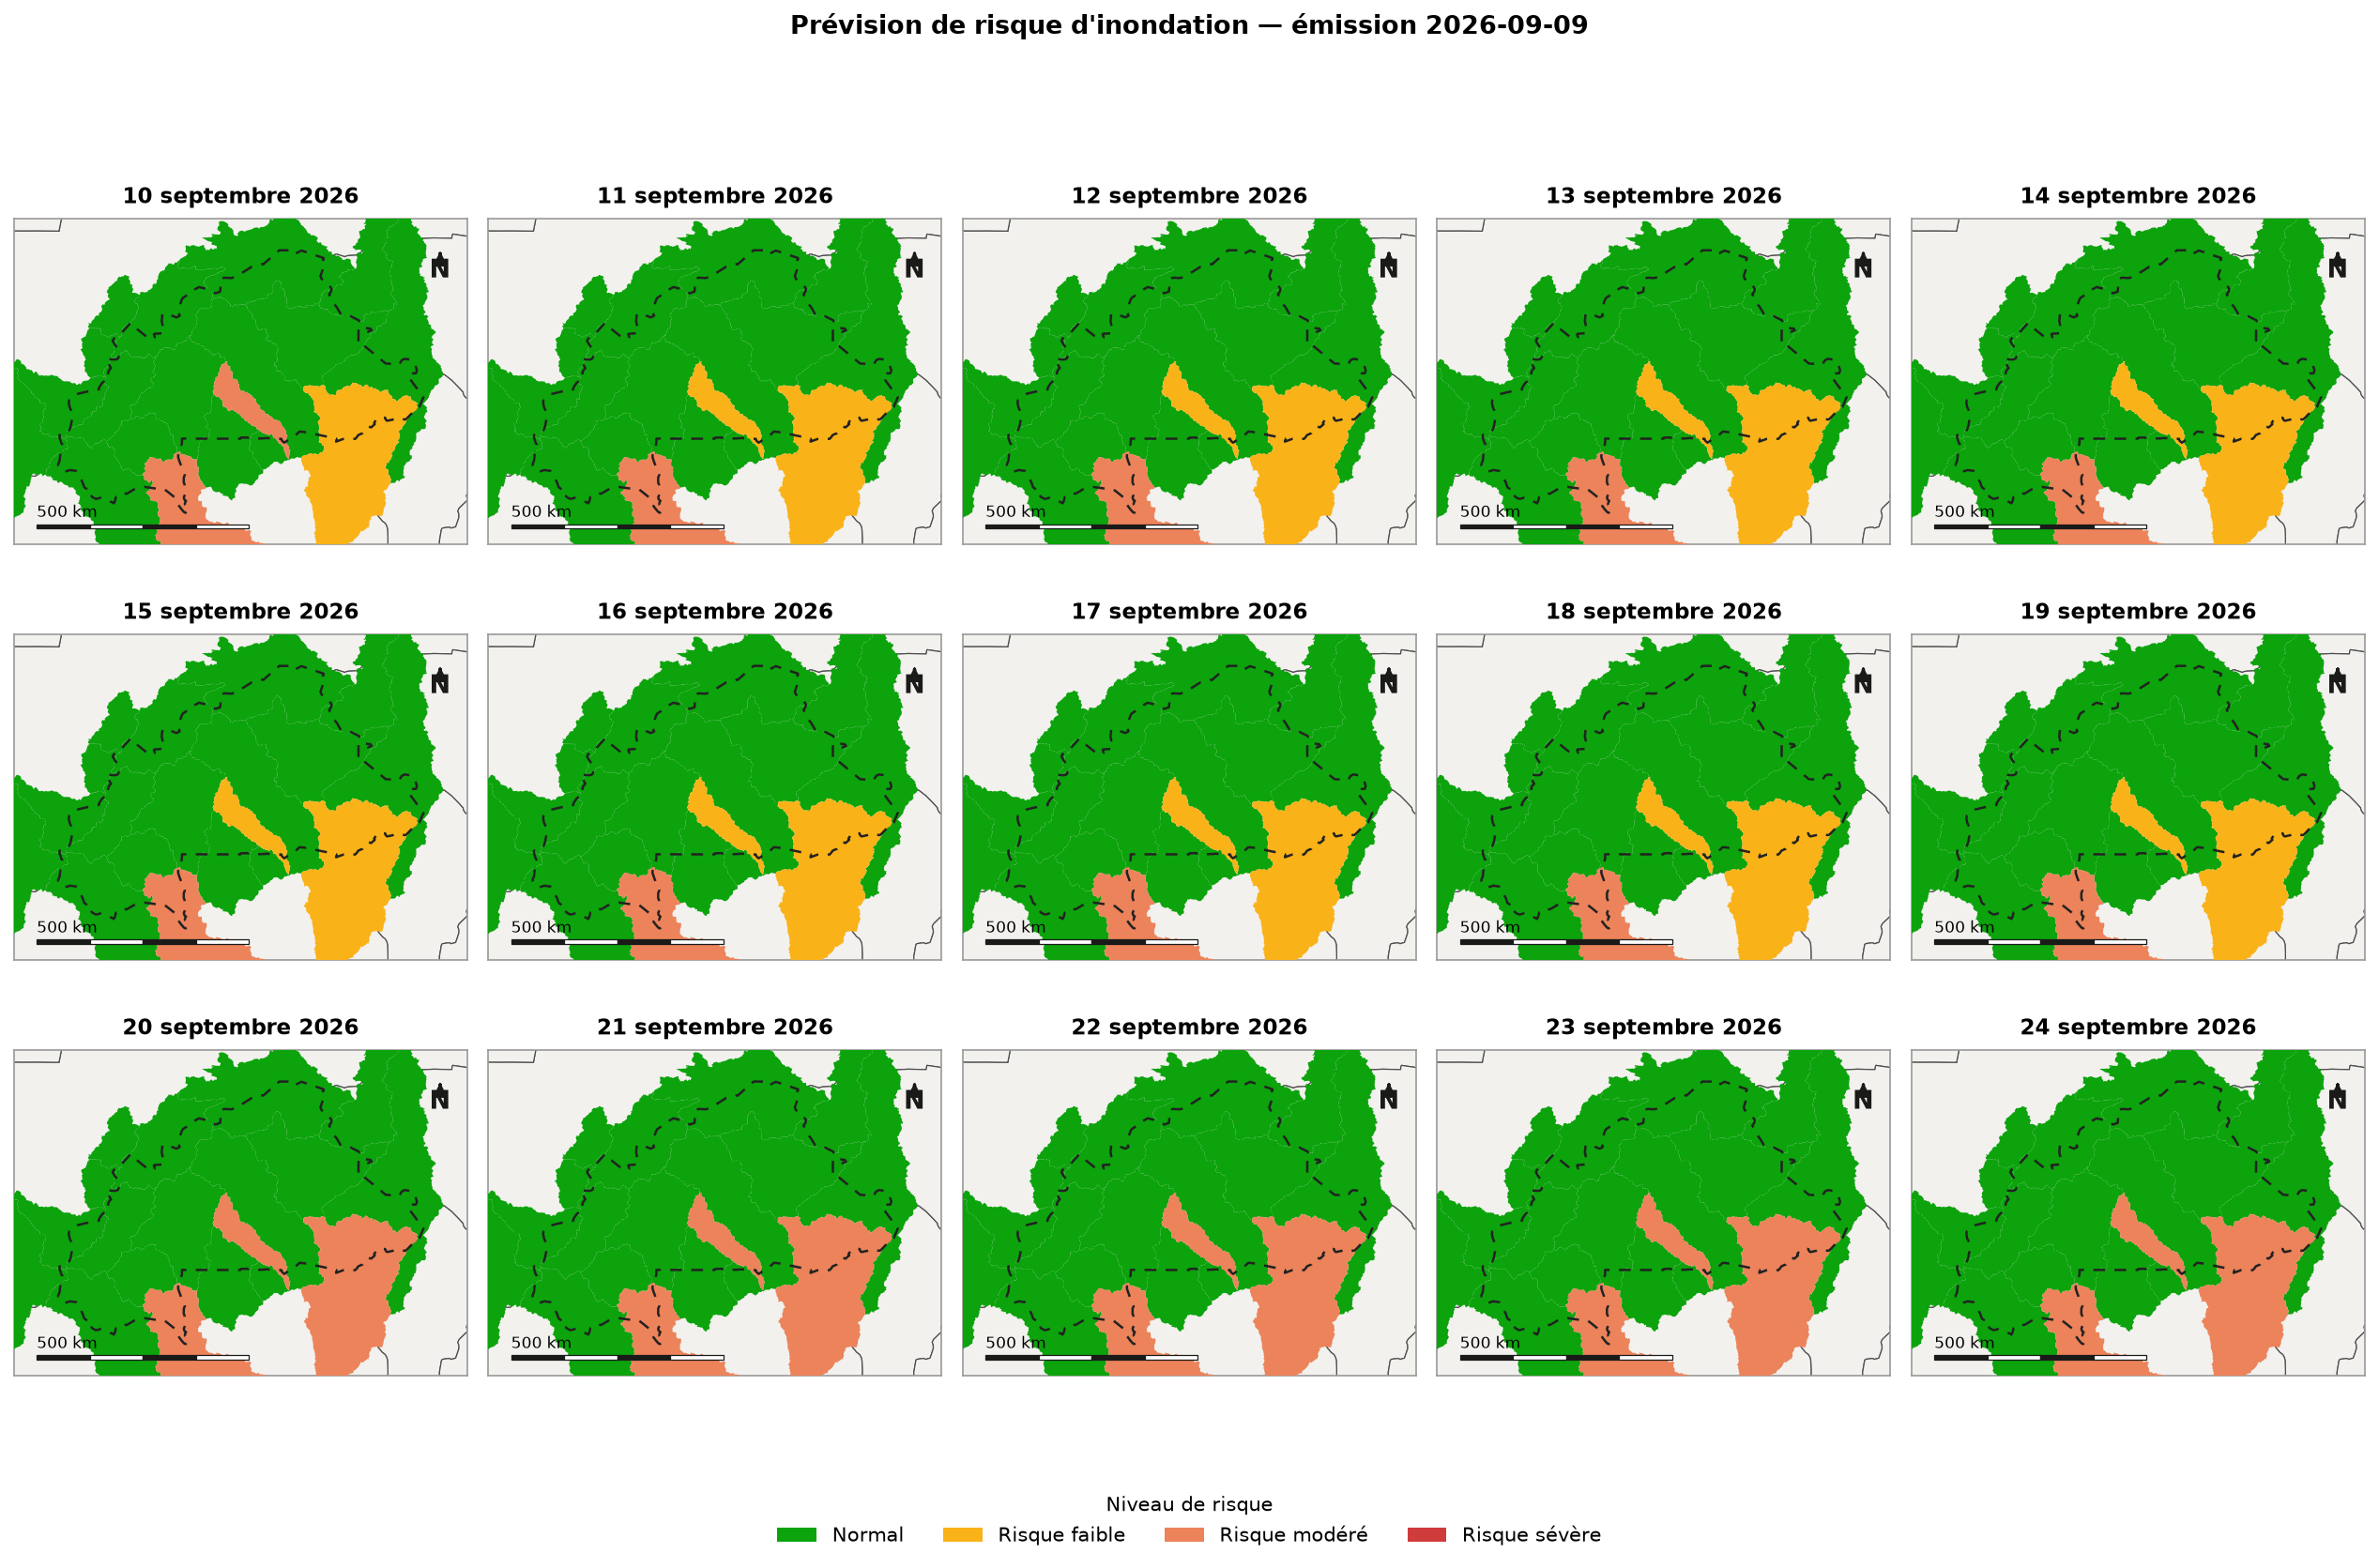

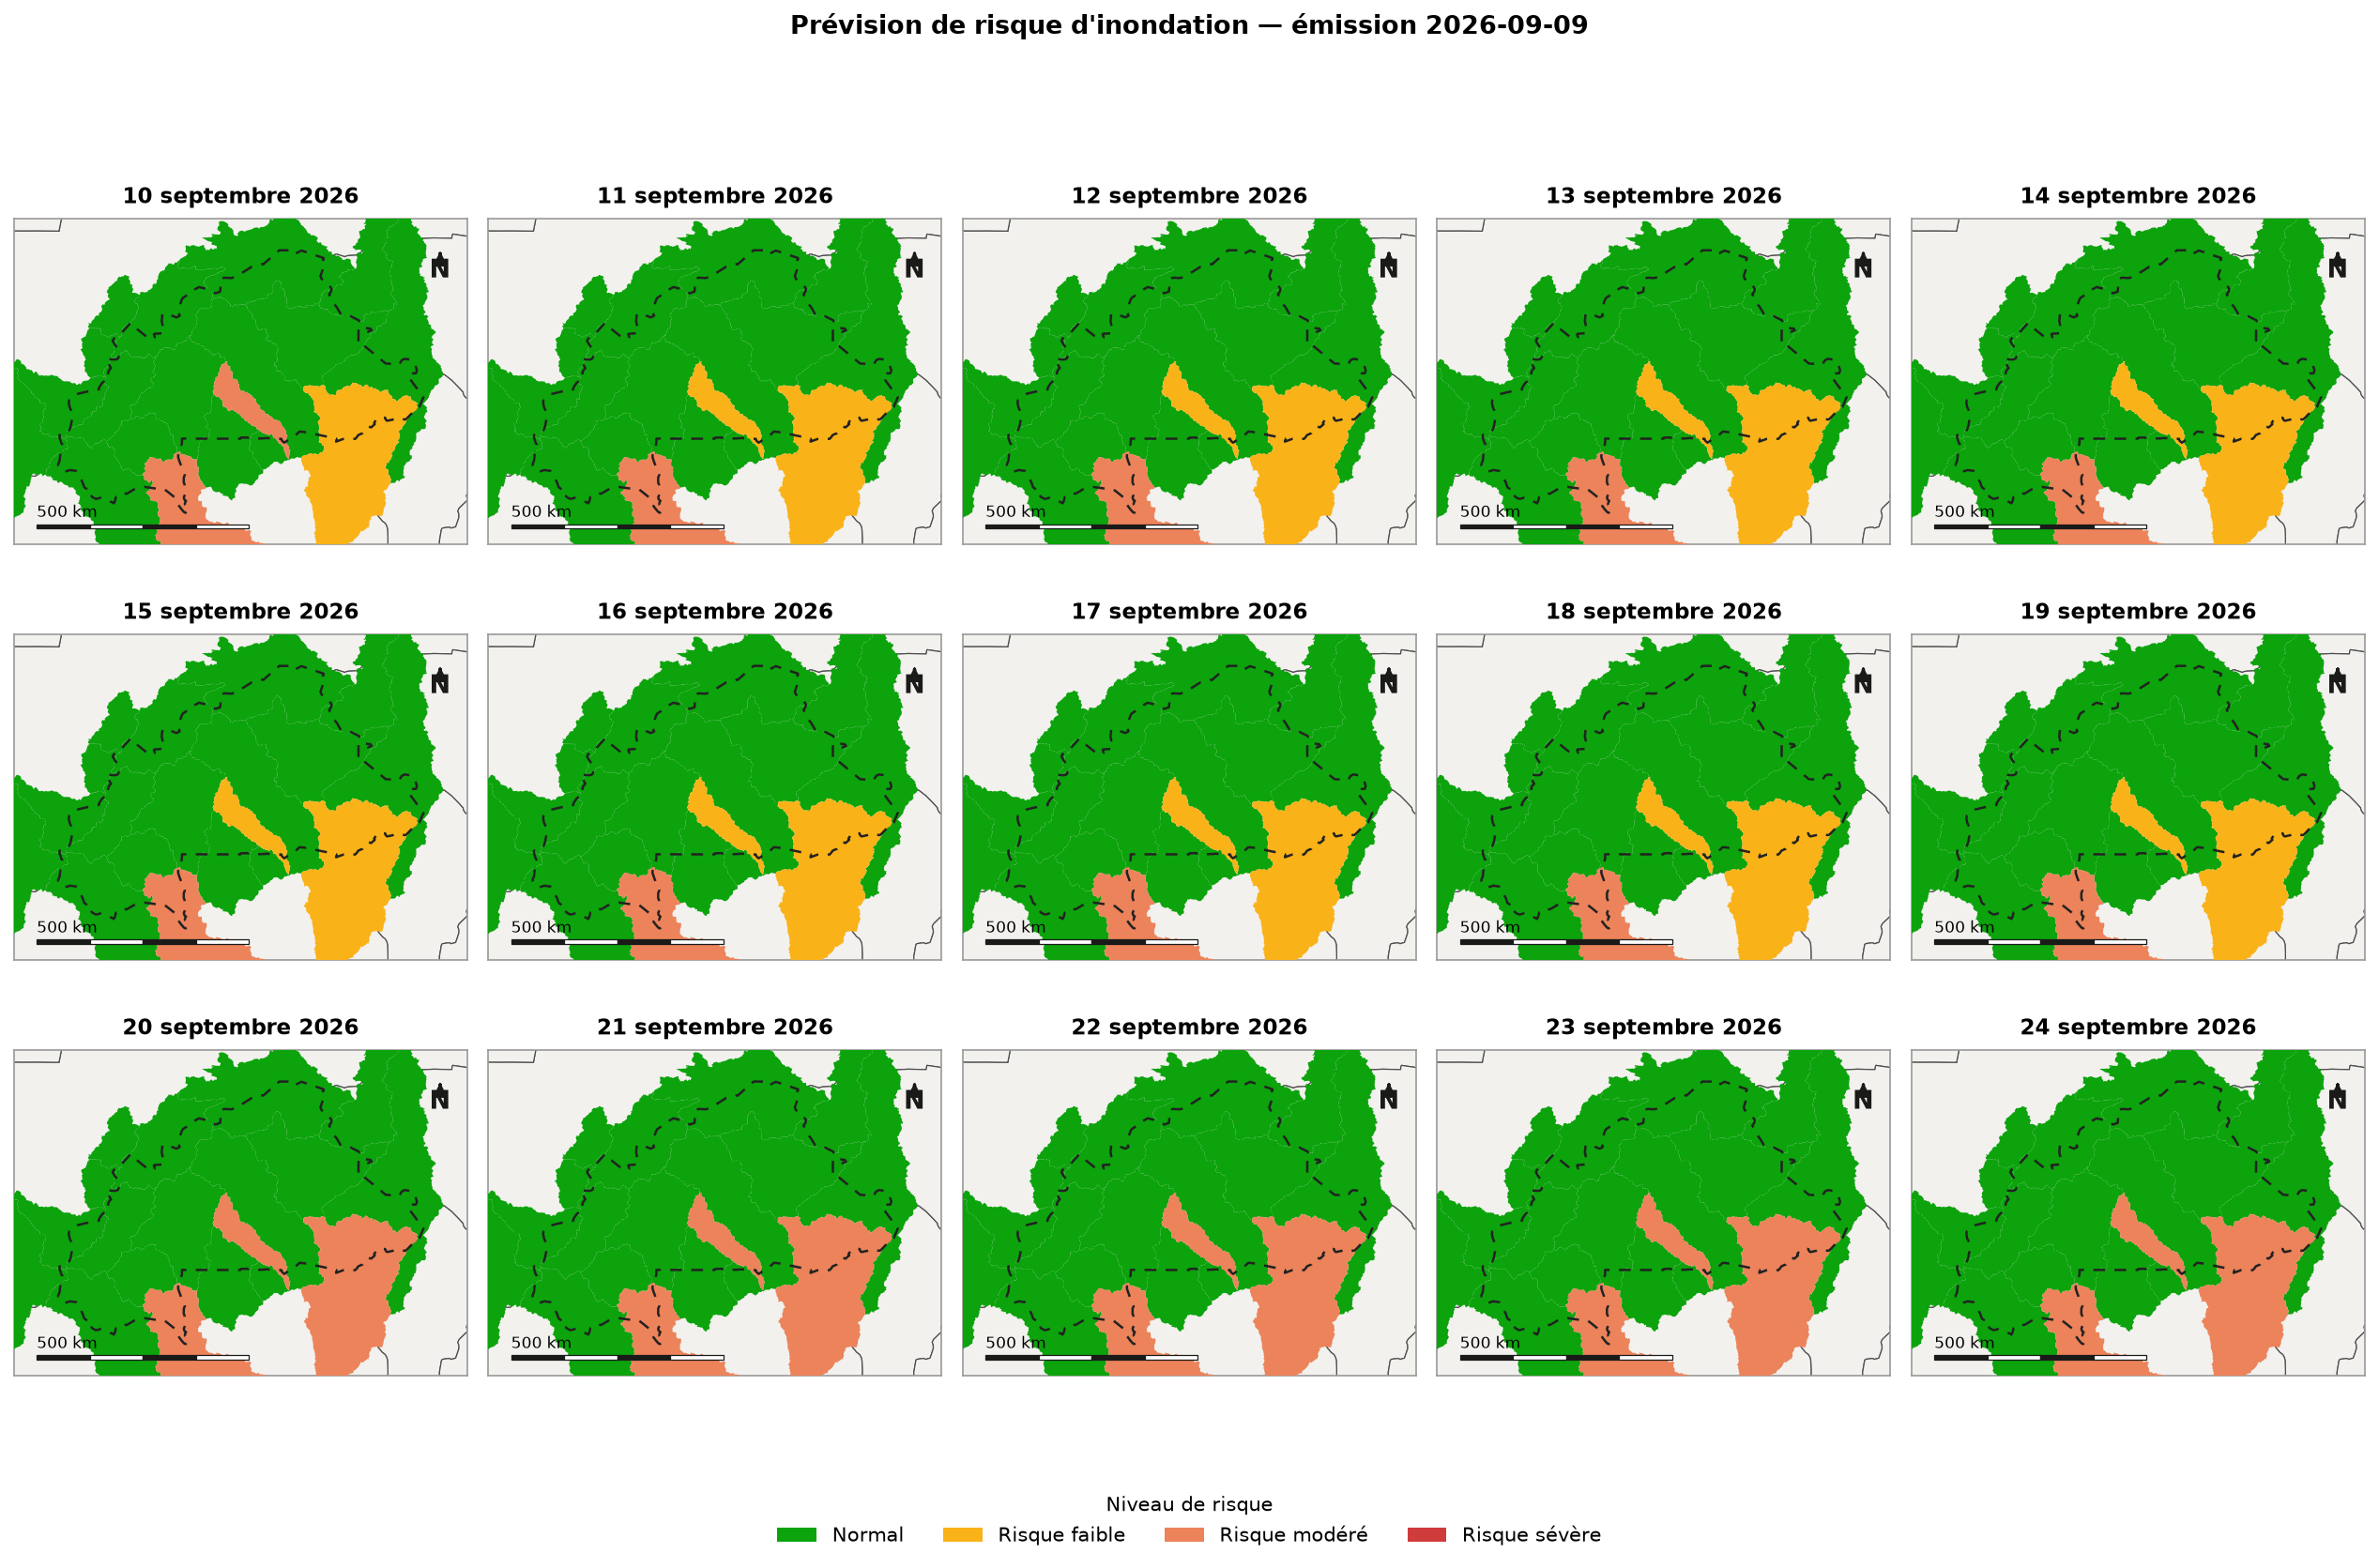

In [45]:
# Toutes les échéances sur une seule planche (grille + légende partagée)
generate_static_risk_map_grid(
    risque, RESULTS_DIR / "historique_points.csv",
    RESULTS_DIR / "cartes_risque_png" / "planche_risque.png",
    basins=selection, basin_id_col=table.id_col, zone=zone,
)

(<Figure size 1500x1200 with 1 Axes>,
 <Axes: title={'center': "Sévérité maximale du risque d'inondation prévu\ndu 10 septembre 2026 au 24 septembre 2026 (émission 2026-09-09, J+1 à J+15)"}>)

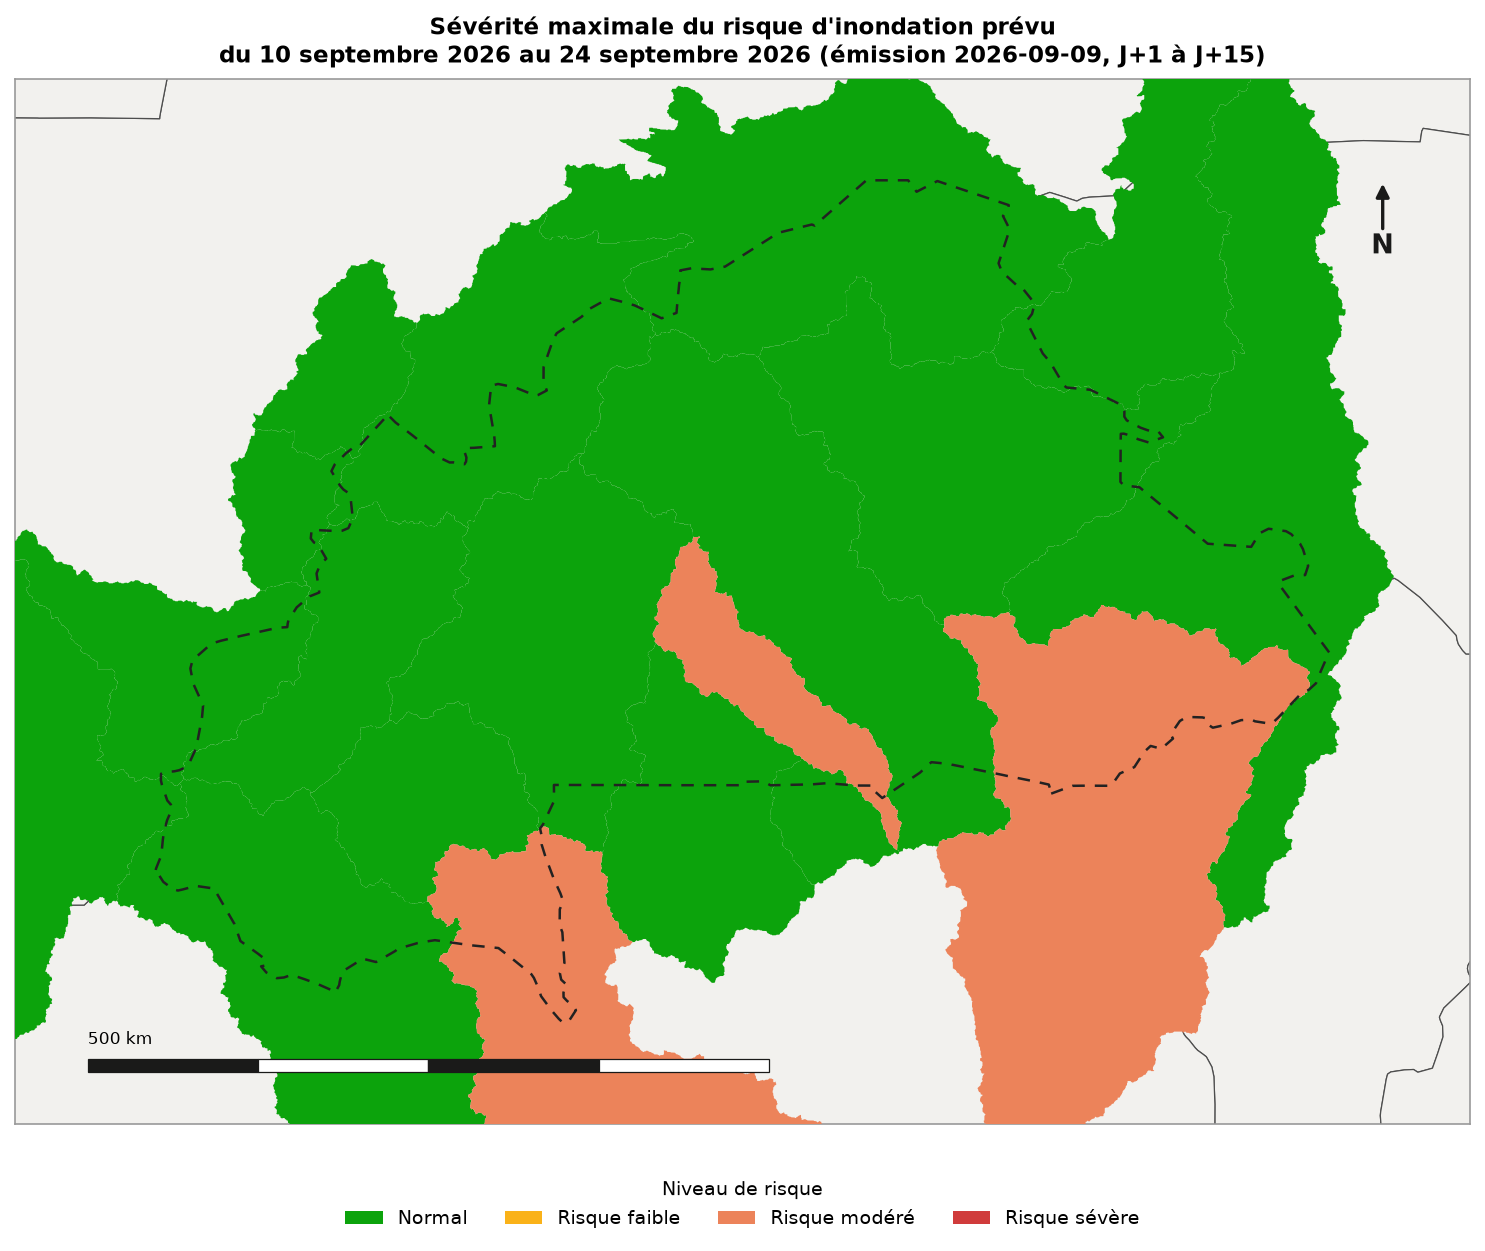

In [46]:
# Sévérité maximale sur toute la période de prévision disponible
build_max_severity_map(
    risque, RESULTS_DIR / "historique_points.csv",
    RESULTS_DIR / "cartes_risque_png" / "risque_maximal.png",
    basins=selection, basin_id_col=table.id_col, zone=zone,
)

---

**Résumé** : `resolve_zone` + `select_basins_in_zone` remplacent la saisie
manuelle d'un fichier de points -- tout le reste (`glofas_download`,
`glofas_extract`, `glofas_forecast`, `glofas_risk`, `glofas_visualize`) est
utilisé exactement comme dans `download_glofas_data.ipynb` et
`previsions_risque.ipynb`, en pointant simplement vers les fichiers de
`resultats/<COUNTRY_NAME>/`.

**Changer de pays/zone** : modifiez uniquement `COUNTRY_NAME` (et `iso3`/
`boundary_path`) à l'étape 1, puis relancez le notebook -- chaque zone a son
propre dossier de résultats (`resultats/<COUNTRY_NAME>/`,
`glofas_data/<COUNTRY_NAME>/`, `glofas_forecast_data/<COUNTRY_NAME>/`), donc
rien n'écrase ni ne mélange les résultats d'une zone précédente.

**Limites à garder en tête** : la sélection `method="outlet"` (défaut) peut
manquer un sous-bassin transfrontalier dont l'exutoire tombe juste à
l'extérieur de la zone (ajustez `buffer_km` ou essayez
`method="intersects"`, si vous disposez du GeoPackage complet avec les
polygones). Les seuils restent des quantiles empiriques, pas des périodes de
retour ajustées statistiquement -- voir les limites déjà notées dans
`previsions_risque.ipynb`.